# **Baseline Models**

A baseline model is a very simple model with no learning, no parameters to tune and often one line of logic. Its purpose is to set the bar other complex models must beat.

Some baseline models:

* `Naive forecast` : Last known value
* `Seasonal Naive` : Last season of data
* `Historic mean` : Mean of data

We must always make these baseline models, as they can be very good.

On this notebook we will create the baseline model our featured XGBoost model will have to beat.



---

### **What is being predicted?**

Spanish day-ahead prices are set by an auction that **closes at 12:00 CET on day D** and covers **all 24 hours of day D+1 simultaneously**.

Hence:

* The horizon is always `h = 24`. One full delivery at once, not a rolling hour-by-hour prediction
* When forecasting, the most recent prices we know are those of **day D**, which cleared the day before and the target is **day D+1**

As a result, every split below reserves the last 24 hours as a test set and trains on everything strictly before it.

This is not a prediction of an unknowable future, it is predicting the outcome of a specific auction before it clears



---

## **01 - Imports and Reading Data**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%pip install statsforecast utilsforecast

# utilsforecast is usefull for visualizing and evaluating with certain metrics the time series
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

import warnings
warnings.filterwarnings('ignore')


Note: you may need to restart the kernel to use updated packages.


In [2]:
from src.paths import DATA_PROCESSED, MODELS_DIR

df = pd.read_csv(DATA_PROCESSED / "spain_day_ahead_hourly_2022_2026_madrid_time.csv",
                 parse_dates=["datetime"])

`StatsForecast` expects three fixed column names:

- `unique_id` — series identifier (we have one single series, so it is a constant)
- `ds` — timestamp
- `y` — target variable

Our columns are `datetime` and `price_eur_mwh`, so we rename and add the identifier.

In [3]:
df.rename(columns={'datetime': 'ds', 'price_eur_mwh': 'y'}, inplace=True)
df['unique_id'] = 'Spain_Hourly_Price'

# Ensure 'ds' column is datetime type
df['ds'] = pd.to_datetime(df['ds'])

display(df.head())

,ds,y,unique_id
0,2022-10-01 00:00:00,167.00,Spain_Hourly_Price
1,2022-10-01 01:00:00,103.80,Spain_Hourly_Price
2,2022-10-01 02:00:00,90.56,Spain_Hourly_Price
3,2022-10-01 03:00:00,85.00,Spain_Hourly_Price
4,2022-10-01 04:00:00,79.22,Spain_Hourly_Price


---
## **02 - Baseline models**

The five models below are chosen to isolate what kind of structure matters:

* `Naive` : tomorrow = last observed price.
* `HistoricAverage` : tomorrow = mean of the whole history.
* `WindowAverage(24)` : tomorrow = mean of the last 24 hours
* `SeasonalNaive(24)` : each hour = same hour yesterday.
* `SeasonalNaive(168)` : each hour = same hour last week.

The first three produce a **flat line** and therfore cannot represent the intraday price shape at all. The two seasonal naive measures, without any  modelling, **how much of the total signal is simply the daily and weekly cycle**

In [4]:
from statsforecast import StatsForecast # Fastest implementation of statistical forecasters
from statsforecast.models import Naive, HistoricAverage, WindowAverage, SeasonalNaive

horizon = 24 #  the day-ahead auction clears the whole next day at once. Hence, h is always 24

# Baseline models: simple rules to beat. If a complex model can't beat these, it isn't worth it.
models = [
    Naive(),                                               # tomorrow = the very last known price (flat line)
    HistoricAverage(),                                     # tomorrow = average of the whole history (flat line)
    WindowAverage(window_size=24),                         # tomorrow = average of the last 24 hours (flat line)
    SeasonalNaive(season_length=24, alias = 'SN Daily'),   # each hour of tomorrow = same hour yesterday (copies the daily shape)
    SeasonalNaive(season_length=168, alias = 'SN Weekly')  # each hour of tomorrow = same hour last week (copies the weekly shape)
]

# StatsForecast handles fitting, predicting, cross-validation... freq="H" = hourly data
sf = StatsForecast(models=models, freq = "H")

# Fit all models on the full series
sf.fit(df=df)

# Make predictions
preds = sf.predict(h = horizon)

preds.head()

,unique_id,ds,Naive,HistoricAverage,WindowAverage,SN Daily,SN Weekly
0,Spain_Hourly_Price,2026-08-15 00:00:00,177.5175,72.924558,140.086042,181.8300,181.2475
1,Spain_Hourly_Price,2026-08-15 01:00:00,177.5175,72.924558,140.086042,179.4250,174.1150
2,Spain_Hourly_Price,2026-08-15 02:00:00,177.5175,72.924558,140.086042,182.4375,170.8025
3,Spain_Hourly_Price,2026-08-15 03:00:00,177.5175,72.924558,140.086042,175.0000,166.6050
4,Spain_Hourly_Price,2026-08-15 04:00:00,177.5175,72.924558,140.086042,170.7900,165.0350


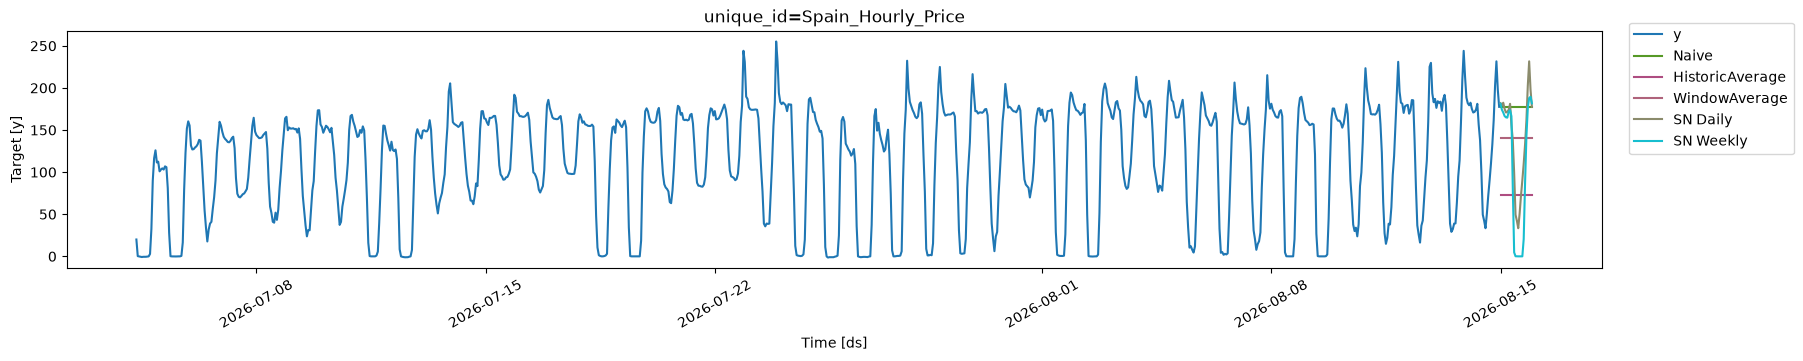

In [5]:
plot_series(
    df = df,
    forecasts_df = preds,
    max_insample_length = 1000
)

---
## **03 - How are the models perfoming?**

We have now predicted the future. However, we do not know how the models are performing. Because we made predictions for timesteps which we don't actually know the value.

To measure error we will use a `test/train` split.

In [6]:
test = df.tail(24) # we reserve the last 24 hours for the test set
train = df.drop(test.index).reset_index(drop=True)

sf.fit(df=train)
preds = sf.predict(h = horizon)

# Evaluation dataframe (where we have the actual values and predictions)
eval_df = pd.merge(test, preds, 'left', ['ds','unique_id'])

evaluation = evaluate(
    eval_df,
    metrics=[mae],    # mean absolute error, in EUR/MWh
)

evaluation.head()


,unique_id,metric,Naive,HistoricAverage,WindowAverage,SN Daily,SN Weekly
0,Spain_Hourly_Price,mae,53.920417,76.924859,48.758628,11.236979,21.055313


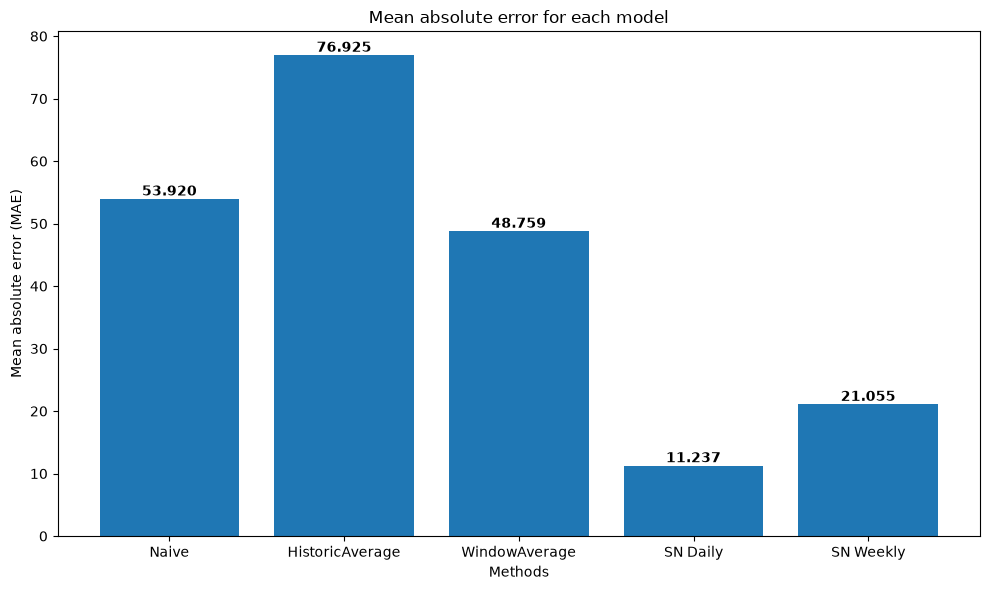

In [7]:
methods = evaluation.columns[2:].tolist()
values = evaluation.iloc[0,2:].tolist()

plt.figure(figsize=(10,6))
bars = plt.bar(methods, values)

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{value:.3f}', ha ='center', va='bottom', fontweight ='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.title('Mean absolute error for each model')
plt.tight_layout()
plt.show()

### **Baseline comparison**

There is a clear split between models that ignore the time of day (`HistoricAverage`, `Naive`, `WindowAverage`, all with **48–77 MAE**) and those that reproduce the daily shape (`SN Daily` and `SN Weekly`). `SN Daily` is the clear winner at **11.24 MAE**: predicting each hour of tomorrow with the same hour of today works because the 24-hour price profile repeats almost identically from one day to the next. `SN Weekly` (**21.06**) is second, the weekly pattern also carries signal, but the previous day is a closer reference than the previous week.

`SN Daily` will set the bar the `XGBoost` model must beat

---
## **04 - ARIMA(p, d, q)**

---

 ARIMA is a flexible model that can forecast series with a trend and **one** seasonal period. It is the standard referenct in time series.

 In this case, the one seasonal period will be the 24 hour cycle


The formula is built by combining two independent processes: **AR(p)** and **MA(q)**.

---

### **1. AR(p) Component (Autoregressive)**

This component looks at the **past values of the series itself**. It shows that today's value depends on its own previous values.

### **2. MA(q) Component (Moving Average)**

This component looks at the **past prediction errors**. It adjusts today's value based on recent unexpected shocks or surprises in the system.

---

### **Combined Formula: ARIMA(p, d, q)**
When we merge both components into a single equation, the model describes the series $Y_t$ (which represents the original data after being **differenced $d$ times**):

$$Y_t = c + \underbrace{\phi_1 Y_{t-1} + \dots + \phi_p Y_{t-p}}_{\text{AR}(p)} + \underbrace{\theta_1 \varepsilon_{t-1} + \dots + \theta_q \varepsilon_{t-q}}_{\text{MA}(q)} + \varepsilon_t$$

In short, the formula tells us that today's value ($Y_t$) is a mix of:
1. A baseline constant ($c$).
2. A weighted combination of its own history up to **$p$ periods** ago.
3. A weighted correction of the prediction mistakes made up to **$q$ periods** ago.
4. A completely new surprise factor today ($\varepsilon_t$).


In [8]:
# Import AutoARIMA function because it finds optimal parameter combination
from statsforecast.models import AutoARIMA

# AutoARIMA is slow, so we train it on a short recent window instead of all 4 years.
# This is fine for ARIMA: it models short-term structure and doesn't benefit from
# distant history, and older data (2022 gas crisis) would bias it anyway.

test  = df.tail(24)                   # last day = test
train = df.drop(test.index)           # everything before the test day
train_arima = train.tail(60*24)       # last 60 days before the test -> enough for the daily cycle, trains fast


models2 = [
    AutoARIMA(seasonal = 1, alias='ARIMA'),       # no seasonality
    AutoARIMA(season_length = 24, alias='SARIMA') # daily seasonality (24h cycle)
    #AutoARIMA(season_length = 168, alias='SARIMA_Weekly') -> weekly cycle: too slow (hours). Skipped
]

sf2 = StatsForecast(models=models2, freq = "H")

sf2.fit(df=train_arima)                   # train once on the 60-day window
arima_preds = sf2.predict(h = horizon)    # predict the next 24h (tomorrow)

# Keep only rows where predictions and actuals share the same timestamp, then score
arima_eval_df = pd.merge(arima_preds, eval_df,'inner', ['ds','unique_id'])

arima_eval = evaluate(
    arima_eval_df,
    metrics=[mae] # mean absolute error
)

arima_eval.head()

,unique_id,metric,ARIMA,SARIMA,Naive,HistoricAverage,WindowAverage,SN Daily,SN Weekly
0,Spain_Hourly_Price,mae,31.79242,10.469433,53.920417,76.924859,48.758628,11.236979,21.055313


SARIMA is configured with `season_length=24`, capturing the dominant daily cycle. **It cannot simultaneously model the weekly cycle** (SARIMA supports only **one** seasonal period), which is a fundamental limitation of the model.

Capturing both daily and weekly seasonality, plus the weekend effect, is precisely what motivates moving to a feature-based model (XGBoost), where hour, day-of-week, and multiple lags can all be provided together.

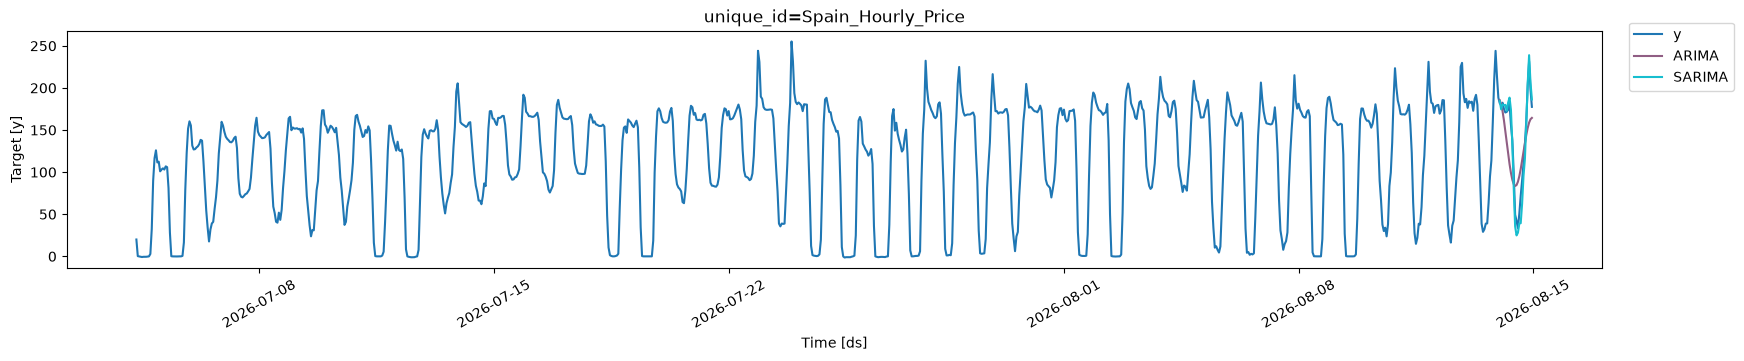

In [9]:
plot_series(
    df = df,
    forecasts_df = arima_preds,
    max_insample_length = 1000
)

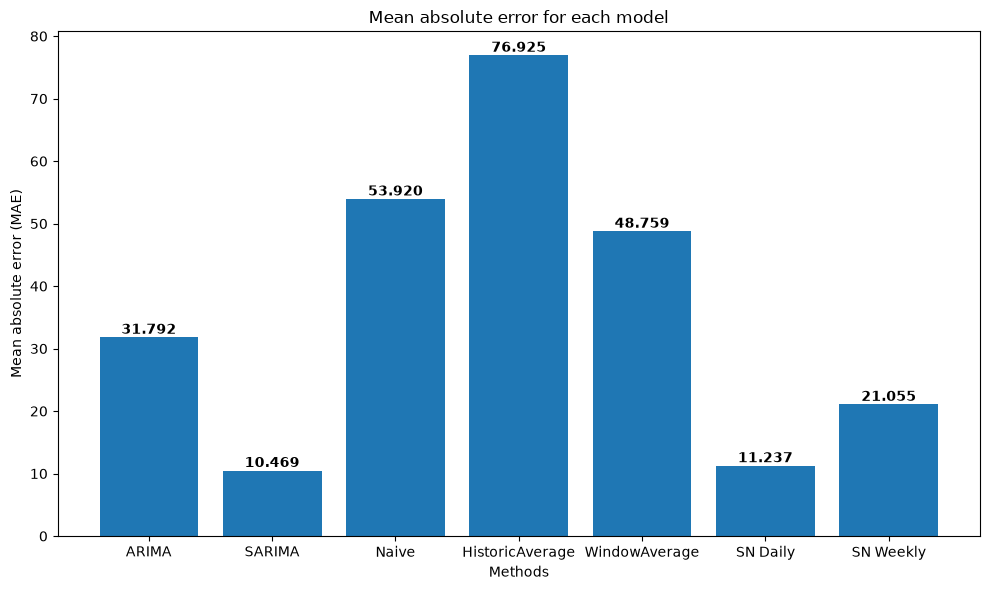

In [10]:
methods = arima_eval.columns[2:].tolist()
values = arima_eval.iloc[0,2:].tolist()

plt.figure(figsize=(10,6))
bars = plt.bar(methods, values)

for bar, value in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{value:.3f}', ha ='center', va='bottom', fontweight ='bold')

plt.xlabel('Methods')
plt.ylabel('Mean absolute error (MAE)')
plt.title('Mean absolute error for each model')
plt.tight_layout()
plt.show()

---
## **05 - Cross-validation**

Instead of testing on a single day like the test/train split , which could be lucky, we test on several separate days and average the error. Which results on a more reliable score.

In [11]:
# Our best 4 models
models3 = [
    SeasonalNaive(season_length=24, alias = 'SN Daily'),    # tomorrow = same hours as yesterday
    SeasonalNaive(season_length=168, alias = 'SN Weekly'),  # tomorrow = same hours as last week
    AutoARIMA(season_length=1, alias='ARIMA'),          # no seasonality
    AutoARIMA(season_length=24, alias='SARIMA')             # daily seasonality (24h cycle)
]

sf3 = StatsForecast(models3, freq='H')
cv_df = sf3.cross_validation(
    h=horizon,          # predict 24h (one day) each window
    df=df.tail(60*24),  # last 60 days (enough for the daily cycle; ARIMA trains fast)
    n_windows=10,       # move 24h each window -> no overlap between test days
    step_size=horizon,  # This way we dont have overlapping windows
    refit=False         # train once, then slide (fast; refit=True would retrain each window)
)


cv_df.head()

,unique_id,ds,cutoff,y,SN Daily,SN Weekly,ARIMA,SARIMA
0,Spain_Hourly_Price,2026-08-05 00:00:00,2026-08-04 23:00:00,183.5275,184.7650,171.1650,181.461338,181.374127
1,Spain_Hourly_Price,2026-08-05 01:00:00,2026-08-04 23:00:00,173.8725,183.0750,167.1400,178.358338,178.012421
2,Spain_Hourly_Price,2026-08-05 02:00:00,2026-08-04 23:00:00,164.7650,180.4900,167.7750,171.993223,177.035664
3,Spain_Hourly_Price,2026-08-05 03:00:00,2026-08-04 23:00:00,164.9675,166.6675,168.4625,161.954266,166.664535
4,Spain_Hourly_Price,2026-08-05 04:00:00,2026-08-04 23:00:00,165.1600,165.1375,168.4000,149.692717,165.620615


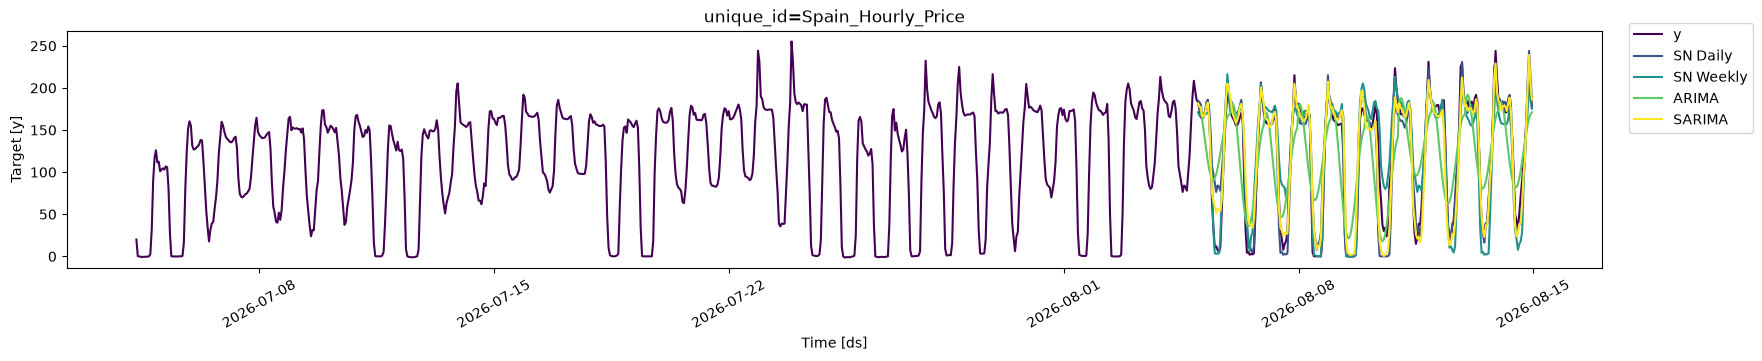

In [12]:
plot_series(
    df = df.tail(60*24),
    forecasts_df = cv_df.drop(['y','cutoff'], axis=1),
    max_insample_length = 1000,
    palette='viridis'
)

In [13]:
# Average MAE across all 10 test windows, per model
cv_eval = evaluate(
    cv_df.drop(['cutoff'],axis=1),
    metrics = [mae]
)
cv_eval

,unique_id,metric,SN Daily,SN Weekly,ARIMA,SARIMA
0,Spain_Hourly_Price,mae,15.500229,18.755823,37.211505,14.459715



We use **MAE** because we want all errors to count equally and need a metric that stays robust against extreme outliers

Under **cross-validation** the MAE values are higher than the single-day evaluation from before (e.g. `SARIMA` **14.46 MAE vs ~10 MAE** earlier). This is not because cross-validation adds error, it's because a single test day can be unusually easy, giving an optimistic score, while averaging over 10 different days gives a more realistic estimate. `SARIMA` remains the strongest baseline model at **14.46 MAE**, narrowly beating `SN Daily` (**15.50 MAE**).

This is the bar `XGBoost` must beat, evaluated on the same 10 cross-validation windows to keep the comparison fair.

---

## **06 - Conclusion**

**1. Most of the easily predictable signal is the daily cycle.** Every flat-line model sits in the 48–77 MAE range while `SN Daily` sits near 11–15. No modelling is required to extract that, just copying yesterday's 24-hour profile already captures the bulk of the structure. Any model that does not comfortably beat `SN Daily` has learned nothing beyond the obvious.


**2. `SARIMA` is the model to beat, but barely.** `SARIMA` has more computation, and it is structurally incapable of representing the weekly cycle simultaneously with the daily one. Hence the decision of moving to a feature-based model rather than tuning the statistical one further.


### **Limitations**

- **20 test days is still a small sample.** It is a defensible trade-off against AutoARIMA's fitting cost, but the confidence intervals around these MAE values are wide, and a 5–10% difference between two models here is not conclusive.
- **`refit=False`** means the ARIMA orders and coefficients are estimated once per block and held fixed for the 5 days that follow. In live operation the model would be re-estimated more often.
- **Weekly seasonality is never modelled** by any statistical model here, `SARIMA_Weekly` was skipped on runtime grounds, so the weekly effect is only represented by the crude `SN Weekly` rule.
- **No exogenous variables at all.** Wind, solar and demand forecasts are the dominant physical drivers of Spanish prices and none of the models above can use them. This is a limitation of the *model class*, and removing it is the single biggest reason to move to XGBoost.

---

## **Export artifacts for the Streamlit app**

The app must never train, it reads frozen files. This cell only serialises what the
notebook has already computed: no model is refit here and no forecast is recomputed.

Notebook 04 writes the same two files with the same schema and appends its own rows to them,
so the baselines and XGBoost end up side by side in a single long table.

In [14]:
BASELINE_MODELS = ["SN Daily", "SN Weekly", "ARIMA", "SARIMA"]

# --- long format: one row per (timestamp, model) ---
preds = cv_df.melt(id_vars=["ds", "cutoff", "y"], value_vars=BASELINE_MODELS,
                   var_name="model", value_name="y_pred")

predictions = (preds.rename(columns={"ds": "timestamp", "y": "y_true"})
                    [["timestamp", "model", "y_true", "y_pred"]])

# --- one row of metrics per (model, CV window) ---
# MASE denominator: the MAE of a seasonal-naive (24h) forecast over the history
# strictly before the first test day. Notebook 04 uses the identical definition,
# so the two blocks of cv_metrics.csv are on the same scale and comparable.
insample   = df.loc[df["ds"] < preds["ds"].min(), "y"]
mase_scale = insample.diff(24).abs().mean()

rows = []
for (model, cutoff), g in preds.groupby(["model", "cutoff"]):
    err = g["y"] - g["y_pred"]
    rows.append({
        "model":  model,
        "window": (cutoff + pd.Timedelta(hours=1)).date(),   # the delivery day, D+1
        "mae":    err.abs().mean(),
        "rmse":   np.sqrt((err ** 2).mean()),
        "mase":   err.abs().mean() / mase_scale,
    })

cv_metrics = pd.DataFrame(rows)

# --- write, appending to whatever notebook 04 already put there ---
pred_path = DATA_PROCESSED / "predictions.parquet"
met_path  = DATA_PROCESSED / "cv_metrics.csv"

if pred_path.exists():
    old = pd.read_parquet(pred_path)
    # re-running this notebook replaces its own rows instead of duplicating them
    old = old[~old["model"].isin(BASELINE_MODELS)]
    predictions = pd.concat([old, predictions], ignore_index=True)

if met_path.exists():
    old = pd.read_csv(met_path)
    old = old[~old["model"].isin(BASELINE_MODELS)]
    cv_metrics = pd.concat([old, cv_metrics], ignore_index=True)

predictions.to_parquet(pred_path, index=False)
cv_metrics.to_csv(met_path, index=False)

print(f"predictions.parquet : {len(predictions):,} rows  |  models: {sorted(predictions['model'].unique())}")
print(f"cv_metrics.csv      : {len(cv_metrics)} rows")

cv_metrics.groupby("model")[["mae", "rmse", "mase"]].mean().round(2)

predictions.parquet : 960 rows  |  models: ['ARIMA', 'SARIMA', 'SN Daily', 'SN Weekly']
cv_metrics.csv      : 40 rows


,mae,rmse,mase
model,,,
ARIMA,37.21,45.77,1.89
SARIMA,14.46,19.36,0.74
SN Daily,15.50,20.74,0.79
SN Weekly,18.76,24.11,0.95
